# Amplitude-damping noise-resilience sweep

This notebook benchmarks the **zero-temperature amplitude-damping time-evolution workflow** under a one-parameter hardware-noise sweep.

For each sweep point, it reports:
- mean fidelity over the time grid,
- mean effective success probability over the time grid,
- mean Frobenius distance over the time grid.

The effective success probability here is the **component-weighted retained-shot fraction** across the executed branch runs.


In [31]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from timeevo.ampdamp.ampdamp_channel import (
    paper_time_grid,
    paper_initial_density_matrix,
    paper_initial_state_decomposition,
    exact_amplitude_damping_density_matrix,
    simulate_ampdamp_branch_on_pure_component,
    simulate_ampdamp_branch_on_pure_component_via_method
)

from noise.noise_simulation import (
    SimpleNISQNoiseParameters,
    noisy_single_qubit_measurement,
)
from noise.noise_resilience_common import (
    NoiseSweepSpecification,
    linear_sweep,
    log_sweep,
    run_noise_resilience_sweep,
)
from metric.success_probability import success_probability_from_counts, method_comparison_success_probability


from plot.noise_sweep_plot import (
    default_sweep_xlabel,
    plot_method_comparison_dataframe,
    SweepPlotColumns,
)
from metric.fidelity_frobenius import evaluate_fidelity_frobenius


## Configuration

In [32]:
# ----------------------
# Sweep configuration
# ----------------------
noise_kind = 'amplitude_damping'  # 'amplitude_damping', 'phase_damping', 'depolarizing', 'readout'
parameterization = 'probability'  # 'probability' for all; 'rate' also works for amplitude/phase damping
sweep_values = linear_sweep(0.0, 0.20, 9)
# sweep_values = log_sweep(1e-3, 2e-1, 8)  # alternative

# ----------------------
# Methods to compare
# ----------------------
methods = ['paper_svd', 'sz_nagy']

# ----------------------
# Channel parameters
# ----------------------
gamma_channel = 0.015
times = paper_time_grid(t_max=25.0, num_points=21)
initial_density_matrix = paper_initial_density_matrix()
component_decomposition = paper_initial_state_decomposition()

# ----------------------
# Experiment size
# ----------------------
repeats = 3
shots_ancilla = 4000
shots_tomography = 4000
rng_seed = 20260415

# ----------------------
# Noise-model baseline
# ----------------------
base_noise_params = SimpleNISQNoiseParameters(
    t1_system=np.inf,
    t2_system=np.inf,
    t1_ancilla=np.inf,
    t2_ancilla=np.inf,
    one_qubit_gate_time=1.0,
    two_qubit_gate_time=1.0,
    p1q_depolarizing=0.0,
    p2q_depolarizing=0.0,
    readout_p0_to_1_system=0.0,
    readout_p1_to_0_system=0.0,
    readout_p0_to_1_ancilla=0.0,
    readout_p1_to_0_ancilla=0.0,
)

# ----------------------
# Sweep-spec options
# ----------------------
spec = NoiseSweepSpecification(
    noise_kind=noise_kind,
    sweep_values=sweep_values,
    parameterization=parameterization,
    duration=base_noise_params.two_qubit_gate_time,
    isolate_noise=True,
    apply_to='both',
    depolarizing_mode='both',
    symmetric_readout=True,
)

print('Time points:', len(times))
print('Sweep points:', len(sweep_values))
print('Methods:', methods)
print('Component labels:', [label for _, _, label in component_decomposition])

Time points: 21
Sweep points: 9
Methods: ['paper_svd', 'sz_nagy']
Component labels: ['|1>', '|+>']


## Helper functions used only in this notebook

In [33]:
def hermitize(rho: np.ndarray) -> np.ndarray:
    rho = np.asarray(rho, dtype=complex)
    return 0.5 * (rho + rho.conj().T)


def safe_nanmean(values) -> float:
    arr = np.asarray(values, dtype=float)
    if arr.size == 0 or np.all(~np.isfinite(arr)):
        return float(np.nan)
    return float(np.nanmean(arr))


def run_ampdamp_noise_case(
    noise_params,
    sweep_value,
    repeat_index,
    rng,
    *,
    times,
    gamma_channel,
    component_decomposition,
    initial_density_matrix,
    shots_ancilla,
    shots_tomography,
    method,
):
    fidelity_values = []
    frobenius_values = []
    effective_success_values = []
    effective_success_exact_values = []

    for time in np.asarray(times, dtype=float):
        exact_total = exact_amplitude_damping_density_matrix(
            float(time),
            initial_density_matrix=initial_density_matrix,
            gamma=gamma_channel,
        )

        obtained_total = np.zeros((2, 2), dtype=complex)
        weighted_success_raw = 0.0
        weighted_success_exact = 0.0

        for weight, ket, label in component_decomposition:
            branch_success_raw = []
            branch_success_exact = []

            for branch in (0, 1):
                branch_seed = int(rng.integers(0, 2**31 - 1))

                result = simulate_ampdamp_branch_on_pure_component_via_method(
                    float(time),
                    method=method,
                    component_weight=float(weight),
                    component_ket=np.asarray(ket, dtype=complex),
                    component_label=str(label),
                    branch=branch,
                    gamma=gamma_channel,
                    noise_params=noise_params,
                    shots=int(shots_tomography),
                    shots_ancilla=int(shots_ancilla),
                    seed=branch_seed,
                    enforce_physical=True,
                )

                obtained_total = obtained_total + np.asarray(result.obtained_subdensity, dtype=complex)

                branch_success_raw.append(
                    method_comparison_success_probability(
                        method,
                        raw_success_probability=result.success_probability_raw,
                    )
                )
                branch_success_exact.append(
                    method_comparison_success_probability(
                        method,
                        raw_success_probability=result.success_probability_exact,
                    )
                )

            weighted_success_raw += float(weight) * safe_nanmean(branch_success_raw)
            weighted_success_exact += float(weight) * safe_nanmean(branch_success_exact)

        obtained_total = hermitize(obtained_total)
        metrics = evaluate_fidelity_frobenius(exact_total, obtained_total)

        fidelity_values.append(metrics.fidelity)
        frobenius_values.append(metrics.frobenius_distance)
        effective_success_values.append(weighted_success_raw)
        effective_success_exact_values.append(weighted_success_exact)

    return {
        'method': str(method),
        'fidelity': float(np.nanmean(fidelity_values)),
        'frobenius_distance': float(np.nanmean(frobenius_values)),
        'success_probability': safe_nanmean(effective_success_values),
        'success_probability_exact': safe_nanmean(effective_success_exact_values),
        'num_times': int(len(times)),
        'shots_ancilla': int(shots_ancilla),
        'shots_tomography': int(shots_tomography),
        'sweep_value_echo': float(sweep_value),
        'repeat_echo': int(repeat_index),
    }

## Single-point smoke test

In [34]:
rng = np.random.default_rng(rng_seed)

smoke_rows = []
for method in methods:
    smoke = run_ampdamp_noise_case(
        base_noise_params,
        sweep_value=0.0,
        repeat_index=0,
        rng=rng,
        times=times[:5],
        gamma_channel=gamma_channel,
        component_decomposition=component_decomposition,
        initial_density_matrix=initial_density_matrix,
        shots_ancilla=1000,
        shots_tomography=1000,
        method=method,
    )
    smoke_rows.append(smoke)

pd.DataFrame(smoke_rows)

,method,fidelity,frobenius_distance,success_probability,success_probability_exact,num_times,shots_ancilla,shots_tomography,sweep_value_echo,repeat_echo
0,paper_svd,0.999896,0.012672,0.5005,0.5,5,1000,1000,0.0,0
1,sz_nagy,0.999617,0.025439,0.4996,0.5,5,1000,1000,0.0,0


## Run the full resilience sweep

In [35]:
all_raw_results = []
all_summary_results = []

for method in methods:
    sweep_result = run_noise_resilience_sweep(
        run_ampdamp_noise_case,
        base_params=base_noise_params,
        specification=spec,
        repeats=repeats,
        rng_seed=rng_seed,
        runner_kwargs={
            'times': times,
            'gamma_channel': gamma_channel,
            'component_decomposition': component_decomposition,
            'initial_density_matrix': initial_density_matrix,
            'shots_ancilla': shots_ancilla,
            'shots_tomography': shots_tomography,
            'method': method,
        },
    )

    raw_df = sweep_result.raw_results.copy()
    summary_df = sweep_result.summary_results.copy()

    raw_df['method'] = method
    summary_df['method'] = method

    all_raw_results.append(raw_df)
    all_summary_results.append(summary_df)

raw_results = pd.concat(all_raw_results, ignore_index=True)
summary_results = pd.concat(all_summary_results, ignore_index=True)

print('Raw results shape:', raw_results.shape)
print('Summary results shape:', summary_results.shape)
summary_results.head(12)

Raw results shape: (54, 15)
Summary results shape: (18, 22)


,noise_kind,parameterization,sweep_value,fidelity_mean,fidelity_std,frobenius_distance_mean,frobenius_distance_std,success_probability_mean,success_probability_std,success_probability_exact_mean,...,num_times_std,shots_ancilla_mean,shots_ancilla_std,shots_tomography_mean,shots_tomography_std,sweep_value_echo_mean,sweep_value_echo_std,repeat_echo_mean,repeat_echo_std,method
0,amplitude_damping,probability,0.000,0.999929,0.000019,0.010527,0.001556,0.500033,0.000667,0.5000,...,0.0,4000.0,0.0,4000.0,0.0,0.000,0.0,1.0,1.0,paper_svd
1,amplitude_damping,probability,0.025,0.999318,0.000073,0.033678,0.002406,0.512024,0.000414,0.5125,...,0.0,4000.0,0.0,4000.0,0.0,0.025,0.0,1.0,1.0,paper_svd
2,amplitude_damping,probability,0.050,0.997682,0.000088,0.065815,0.001042,0.525489,0.000500,0.5250,...,0.0,4000.0,0.0,4000.0,0.0,0.050,0.0,1.0,1.0,paper_svd
3,amplitude_damping,probability,0.075,0.995045,0.000218,0.099107,0.001777,0.537882,0.000703,0.5375,...,0.0,4000.0,0.0,4000.0,0.0,0.075,0.0,1.0,1.0,paper_svd
4,amplitude_damping,probability,0.100,0.991618,0.000110,0.133540,0.001142,0.549737,0.000637,0.5500,...,0.0,4000.0,0.0,4000.0,0.0,0.100,0.0,1.0,1.0,paper_svd
5,amplitude_damping,probability,0.125,0.987408,0.000127,0.168025,0.001356,0.562117,0.000378,0.5625,...,0.0,4000.0,0.0,4000.0,0.0,0.125,0.0,1.0,1.0,paper_svd
6,amplitude_damping,probability,0.150,0.982519,0.000363,0.203566,0.002085,0.574387,0.000756,0.5750,...,0.0,4000.0,0.0,4000.0,0.0,0.150,0.0,1.0,1.0,paper_svd
7,amplitude_damping,probability,0.175,0.977181,0.000124,0.239786,0.001760,0.588345,0.000990,0.5875,...,0.0,4000.0,0.0,4000.0,0.0,0.175,0.0,1.0,1.0,paper_svd
8,amplitude_damping,probability,0.200,0.971163,0.000204,0.275495,0.000457,0.600309,0.000086,0.6000,...,0.0,4000.0,0.0,4000.0,0.0,0.200,0.0,1.0,1.0,paper_svd
9,amplitude_damping,probability,0.000,0.999929,0.000019,0.010527,0.001556,0.500033,0.000667,0.5000,...,0.0,4000.0,0.0,4000.0,0.0,0.000,0.0,1.0,1.0,sz_nagy


## Inspect raw repeated-run records

In [36]:
raw_results.head(18)

,noise_kind,parameterization,sweep_index,sweep_value,repeat_index,method,fidelity,frobenius_distance,success_probability,success_probability_exact,num_times,shots_ancilla,shots_tomography,sweep_value_echo,repeat_echo
0,amplitude_damping,probability,0,0.000,0,paper_svd,0.999952,0.008735,0.499592,0.5000,21,4000,4000,0.000,0
1,amplitude_damping,probability,0,0.000,1,paper_svd,0.999916,0.011305,0.499705,0.5000,21,4000,4000,0.000,1
2,amplitude_damping,probability,0,0.000,2,paper_svd,0.999920,0.011540,0.500801,0.5000,21,4000,4000,0.000,2
3,amplitude_damping,probability,1,0.025,0,paper_svd,0.999382,0.031879,0.511557,0.5125,21,4000,4000,0.025,0
4,amplitude_damping,probability,1,0.025,1,paper_svd,0.999239,0.036411,0.512170,0.5125,21,4000,4000,0.025,1
5,amplitude_damping,probability,1,0.025,2,paper_svd,0.999332,0.032745,0.512345,0.5125,21,4000,4000,0.025,2
6,amplitude_damping,probability,2,0.050,0,paper_svd,0.997774,0.064952,0.525146,0.5250,21,4000,4000,0.050,0
7,amplitude_damping,probability,2,0.050,1,paper_svd,0.997674,0.065520,0.525259,0.5250,21,4000,4000,0.050,1
8,amplitude_damping,probability,2,0.050,2,paper_svd,0.997598,0.066974,0.526063,0.5250,21,4000,4000,0.050,2
9,amplitude_damping,probability,3,0.075,0,paper_svd,0.995088,0.099340,0.537092,0.5375,21,4000,4000,0.075,0


## Plot fidelity and success probability against the swept parameter

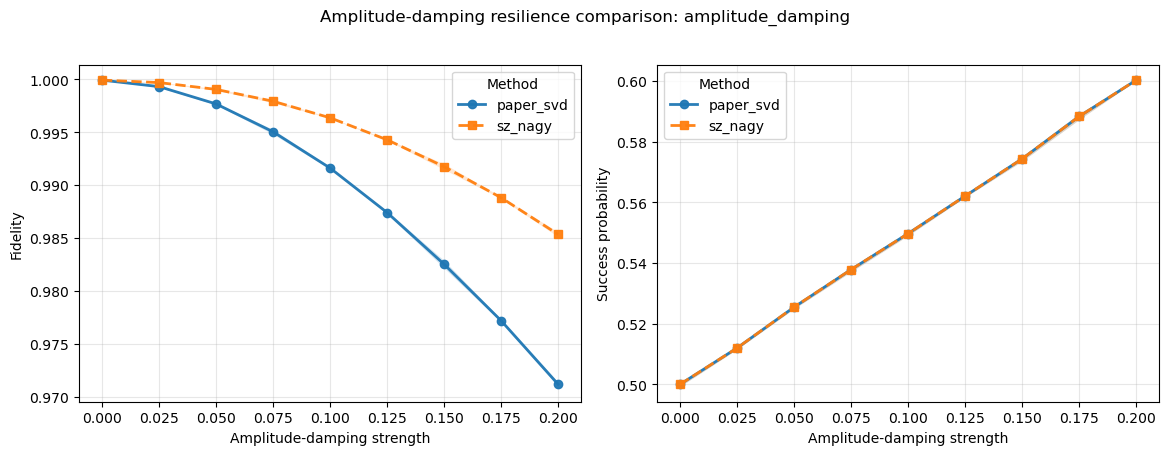

In [37]:
method_line_styles = {
    'paper_svd': '-',
    'sz_nagy': '--',
}

fig, axs = plot_method_comparison_dataframe(
    summary_results,
    method_column='method',
    columns=SweepPlotColumns(
        sweep_value='sweep_value',
        fidelity_mean='fidelity_mean',
        fidelity_std='fidelity_std',
        success_mean='success_probability_mean',
        success_std='success_probability_std',
    ),
    xlabel=default_sweep_xlabel(noise_kind),
    title=f'Amplitude-damping resilience comparison: {noise_kind}',
    colors=['tab:blue', 'tab:orange'],
    markers=['o', 's'],
    line_styles=method_line_styles,
    legend_title='Method',
)
plt.show()

## Saves the figure

In [38]:
out_dir = Path.cwd()
fig.savefig(out_dir / 'ampdamp_ampdamp_resilience.pdf', dpi=200, bbox_inches='tight')
plt.close(fig)